# 07 — Best-Configuration Model Comparison

**Model selection strategy:**
- **Non-linear models (finetuned):** AutoXGBoost, AutoLSTM, AutoRandomForest, AutoNHITS, AutoTFT, AutoPatchTST
  — each series uses the bucket-specific model trained on its tercile (oracle assignment)
- **Linear models (no finetune):** AutoRidge, AutoLinearRegression, AutoNLinear — global baseline
- **Statistical (per-series, no finetune):** AutoARIMA, AutoETS, AutoSARIMA

For each of the above, **all three decomposition strategies** (Direct, STL-SN, STL-AC) are retained,
giving a full grid of best-possible configurations.

**Analyses:**
1. Aggregate MCM matrix (pairwise Wilcoxon + Holm across all features)
2. Performance by decomposition type
3. Per-feature MCM matrices
4. Best (finetune × decomp) config per model per feature + significance


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations

sns.set_theme(style="whitegrid", font_scale=1.0)
DATA = Path("data")

master = pd.read_parquet(DATA / "master_metrics.parquet")

# ── Model groups ──────────────────────────────────────────────────────────────
NL_MODELS   = ["AutoXGBoost","AutoLSTM","AutoRandomForest","AutoNHITS","AutoTFT","AutoPatchTST"]
LIN_MODELS  = ["AutoRidge","AutoLinearRegression","AutoNLinear"]
STAT_MODELS = ["AutoARIMA","AutoETS","AutoSARIMA"]
ALL_MODELS  = NL_MODELS + LIN_MODELS + STAT_MODELS

DECOMP_LABELS = {"without_stl":"Direct","stl_seasonal_naive":"STL-SN",
                 "stl_model_all_components":"STL-AC"}
FAMILY_COLORS = {"statistical":"#4C72B0","mlforecast":"#DD8452",
                 "neuralforecast":"#55A868","transformers":"#C44E52"}
FEAT_SHORT = {
    "feature_non_normality":          "Non-normality",
    "feature_nonlinearity":           "Nonlinearity",
    "feature_spectral_entropy":       "Spectral entropy",
    "feature_evolving_seasonality":   "Evolv. seasonality",
    "feature_structural_break_strength": "Structural break",
    "feature_arch_stat":              "ARCH/volatility",
}
FEATURES = list(FEAT_SHORT.keys())

# ── Build unified performance table ──────────────────────────────────────────
# Non-linear: use bucket-specific finetuned rows (ft_bucket == feature_bucket, always true)
nl = master[
    master["model_name"].isin(NL_MODELS) &
    master["finetuning_mode"].str.startswith("finetune_bucket_")
].copy()
nl["config"] = "finetuned"

# Linear + statistical: use no_finetune global baseline
other = master[
    master["model_name"].isin(LIN_MODELS + STAT_MODELS) &
    (master["finetuning_mode"] == "no_finetune")
].copy()
other["config"] = "global"

perf = pd.concat([nl, other], ignore_index=True)
perf["decomp"] = perf["decomposition_method"].map(DECOMP_LABELS)
perf["model_label"] = perf["model_name"] + " (" + perf["config"].str[:2].str.upper() + ")"

print(f"Performance table: {len(perf):,} rows")
print(f"  NL finetuned  : {len(nl):,}")
print(f"  Lin+Stat global: {len(other):,}")
print(f"Unique models: {perf['model_name'].nunique()}")
print(perf.groupby(["config","model_family"])["model_name"].nunique())


Performance table: 1,932,984 rows
  NL finetuned  : 966,492
  Lin+Stat global: 966,492
Unique models: 12


config     model_family  
finetuned  mlforecast        2
           neuralforecast    2
           transformers      2
global     mlforecast        2
           neuralforecast    1
           statistical       3
Name: model_name, dtype: int64


## 1  Overall Performance by Model

All features and decompositions combined.

In [2]:
overall = (
    perf
    .groupby(["model_name","config","model_family","decomposition_method"])["rel_naive_clipped"]
    .agg(mean="mean", median="median", n="count")
    .reset_index()
    .sort_values("median")
)
overall["decomp"] = overall["decomposition_method"].map(DECOMP_LABELS)

# Best config per model (lowest median)
best = overall.loc[overall.groupby("model_name")["median"].idxmin()].copy()
best = best.sort_values("median").reset_index(drop=True)
best.insert(0, "rank", best.index + 1)
print("Best configuration per model:")
print(best[["rank","model_name","config","decomp","mean","median","n"]].to_string(index=False))
best.to_csv(DATA / "table_best_config_overall.csv", index=False)


Best configuration per model:
 rank           model_name    config decomp     mean   median     n
    1              AutoETS    global Direct 0.888421 0.791368 53694
    2            AutoARIMA    global Direct 0.940830 0.798309 53694
    3           AutoSARIMA    global Direct 0.940830 0.798309 53694
    4            AutoNHITS finetuned Direct 1.007723 0.823253 53694
    5          AutoNLinear    global STL-AC 0.936657 0.828706 53694
    6            AutoRidge    global STL-AC 0.937404 0.831929 53694
    7 AutoLinearRegression    global STL-AC 0.938124 0.833159 53694
    8              AutoTFT finetuned Direct 1.046935 0.851412 53694
    9         AutoPatchTST finetuned Direct 1.001269 0.854887 53694
   10          AutoXGBoost finetuned Direct 1.114471 0.883304 53694
   11             AutoLSTM finetuned STL-AC 1.064160 0.910189 53694
   12     AutoRandomForest finetuned Direct 1.198933 0.914930 53694


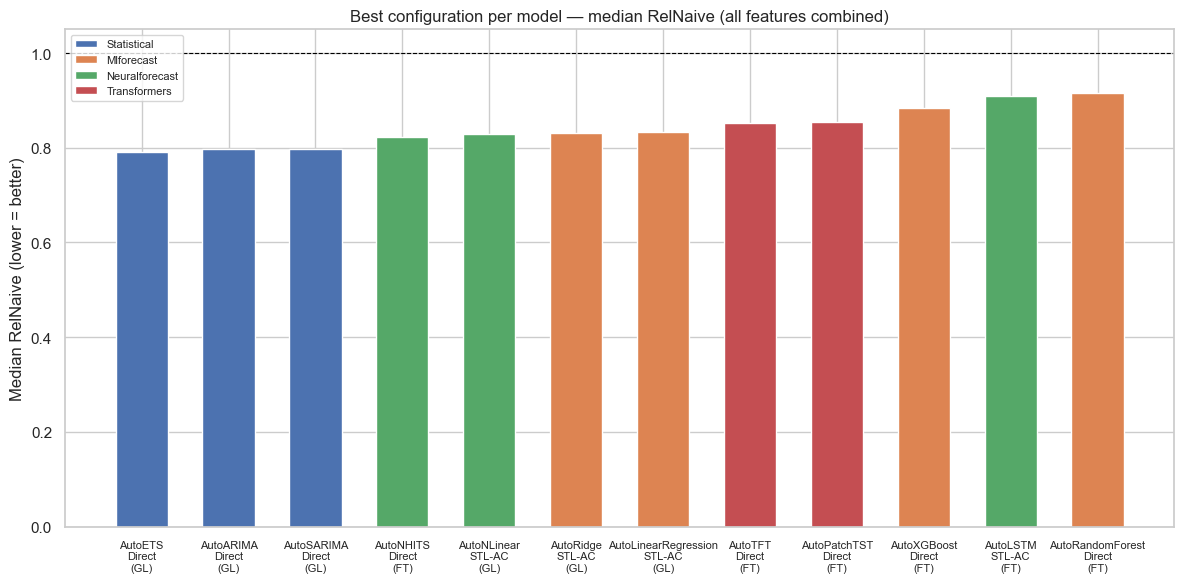

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(best))
colors = [FAMILY_COLORS.get(r["model_family"], "gray") for _, r in best.iterrows()]
bars = ax.bar(x, best["median"], color=colors, edgecolor="white", width=0.6)
ax.axhline(1.0, color="black", lw=0.8, ls="--", label="Naive baseline")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r['model_name']}\n{r['decomp']}\n({'FT' if r['config']=='finetuned' else 'GL'})"
     for _, r in best.iterrows()],
    fontsize=8, ha="center")
ax.set_ylabel("Median RelNaive (lower = better)")
ax.set_title("Best configuration per model — median RelNaive (all features combined)")
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k.capitalize()) for k, v in FAMILY_COLORS.items()]
ax.legend(handles=legend_elements, fontsize=8)
fig.tight_layout()
plt.savefig(DATA / "fig_best_config_overall.png", dpi=150, bbox_inches="tight")
plt.show()


## 2  MCM Matrix — Aggregate (All Features)

Pairwise Wilcoxon signed-rank tests between every model's **best configuration**.
For each pair, tests are run on matched (unique_id, window, decomposition) triplets.
`+1` = row model significantly better; `-1` = column model significantly better; `0` = no significant difference.

In [4]:
def pairwise_mcm(df, model_col, value_col, match_keys, alpha=0.05):
    """Pairwise Wilcoxon tests with Holm correction. Returns win-matrix and p-matrix."""
    models = sorted(df[model_col].unique())
    n = len(models)
    # Collect all test pairs
    pairs, stats_list = [], []
    for i, m1 in enumerate(models):
        for j, m2 in enumerate(models):
            if i >= j: continue
            d1 = df[df[model_col]==m1].set_index(match_keys)[value_col]
            d2 = df[df[model_col]==m2].set_index(match_keys)[value_col]
            common = d1.index.intersection(d2.index)
            if len(common) < 20: continue
            diff = d1.loc[common].values - d2.loc[common].values
            if np.all(diff == 0): continue
            try:
                stat, p = wilcoxon(diff)
                pairs.append((i, j)); stats_list.append((stat, p, diff.mean()))
            except: pass

    # Holm correction
    if not stats_list: return pd.DataFrame(0, index=models, columns=models)
    ps = [x[1] for x in stats_list]
    reject, p_holm, _, _ = multipletests(ps, method="holm")

    win = pd.DataFrame(0, index=models, columns=models)
    for (i, j), (stat, p, mean_diff), rej in zip(pairs, stats_list, reject):
        m1, m2 = models[i], models[j]
        if rej:
            # Negative diff means m1 < m2 (m1 better since lower RelNaive = better)
            if mean_diff < 0:  win.loc[m1, m2] = 1;  win.loc[m2, m1] = -1
            else:              win.loc[m2, m1] = 1;  win.loc[m1, m2] = -1
    return win

# Use best config per model
best_map = dict(zip(best["model_name"],
                    zip(best["config"], best["decomposition_method"])))

# Build best-config subset
rows = []
for model, (cfg, decomp) in best_map.items():
    sub = perf[(perf["model_name"]==model) &
               (perf["decomposition_method"]==decomp)].copy()
    rows.append(sub)
perf_best = pd.concat(rows, ignore_index=True)

match_keys = ["feature_name","unique_id","window"]
print("Running MCM matrix (aggregate, all features)...")
mcm = pairwise_mcm(perf_best, "model_name", "rel_naive_clipped", match_keys)
print("Done.")
print(f"Wins (row beats column): {(mcm==1).sum().sum()}")
print(f"Losses: {(mcm==-1).sum().sum()}")
print(f"Ties:   {(mcm==0).sum().sum()}")


Running MCM matrix (aggregate, all features)...


Done.
Wins (row beats column): 63
Losses: 63
Ties:   18


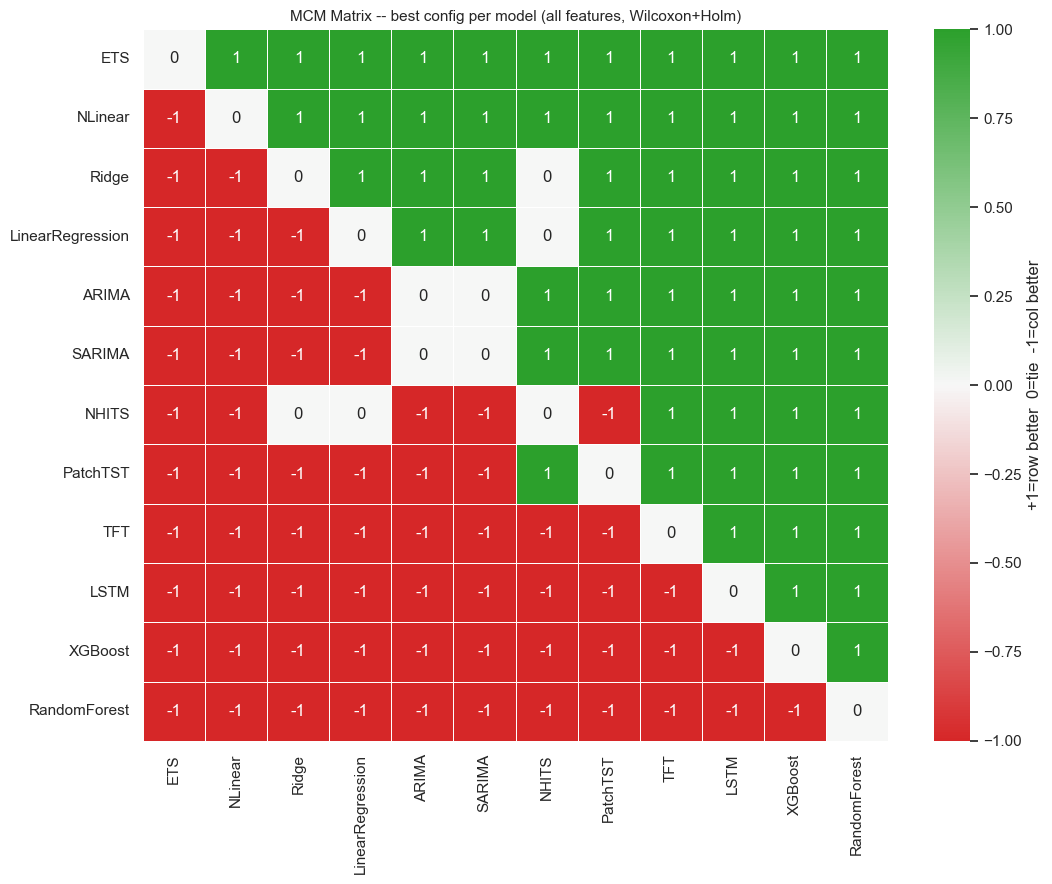

Net win score (best config, all features):
  AutoETS                   score=+11  (global, Direct)
  AutoNLinear               score= +9  (global, STL-AC)
  AutoRidge                 score= +6  (global, STL-AC)
  AutoLinearRegression      score= +4  (global, STL-AC)
  AutoARIMA                 score= +2  (global, Direct)
  AutoSARIMA                score= +2  (global, Direct)
  AutoNHITS                 score= -1  (finetuned, Direct)
  AutoPatchTST              score= -1  (finetuned, Direct)
  AutoTFT                   score= -5  (finetuned, Direct)
  AutoLSTM                  score= -7  (finetuned, STL-AC)
  AutoXGBoost               score= -9  (finetuned, Direct)
  AutoRandomForest          score=-11  (finetuned, Direct)


In [5]:
order = mcm.sum(axis=1).sort_values(ascending=False).index.tolist()
mcm_ordered = mcm.loc[order, order]
short = {m: m.replace("Auto", "") for m in order}
mcm_plot = mcm_ordered.rename(index=short, columns=short)

fig, ax = plt.subplots(figsize=(11, 9))
cmap = mcolors.LinearSegmentedColormap.from_list("mcm", ["#d62728","#f7f7f7","#2ca02c"])
sns.heatmap(mcm_plot, ax=ax, cmap=cmap, center=0, vmin=-1, vmax=1,
            annot=True, fmt="d", linewidths=0.4,
            cbar_kws={"label":"+1=row better  0=tie  -1=col better"})
title = "MCM Matrix -- best config per model (all features, Wilcoxon+Holm)"
ax.set_title(title, fontsize=11)
ax.set_xlabel(""); ax.set_ylabel("")
fig.tight_layout()
plt.savefig(DATA / "fig_mcm_aggregate.png", dpi=150, bbox_inches="tight")
plt.show()

wins = mcm.sum(axis=1).sort_values(ascending=False)
print("Net win score (best config, all features):")
for m, w in wins.items():
    cfg, decomp = best_map[m]
    print(f"  {m:<25} score={w:+3d}  ({cfg}, {DECOMP_LABELS[decomp]})")
wins.to_csv(DATA / "table_mcm_win_scores.csv")


## 3  Performance by Decomposition Method

For each decomposition, how do all model configurations compare?

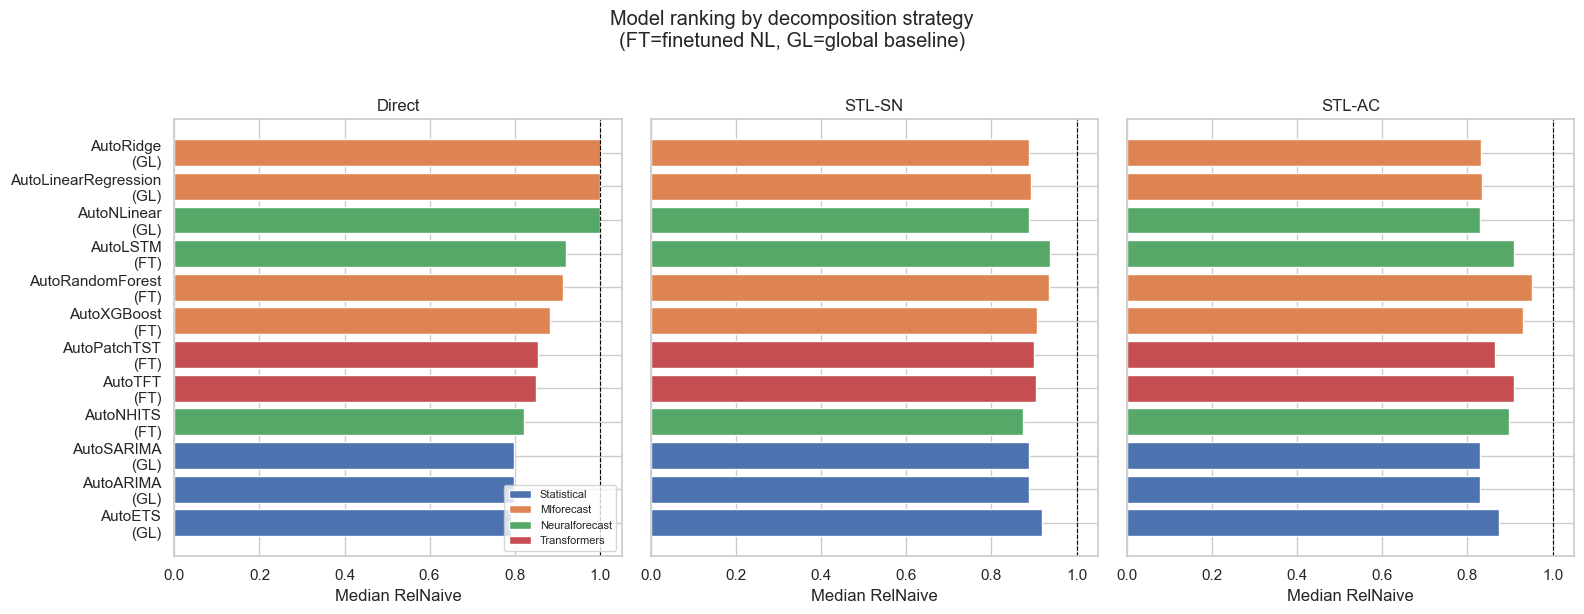

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True)
decomps = ["without_stl","stl_seasonal_naive","stl_model_all_components"]

for ax, decomp in zip(axes, decomps):
    sub = perf[perf["decomposition_method"]==decomp].copy()
    rank = (sub.groupby(["model_name","config","model_family"])["rel_naive_clipped"]
            .median().reset_index().sort_values("rel_naive_clipped"))
    colors = [FAMILY_COLORS.get(r["model_family"],"gray") for _, r in rank.iterrows()]
    labels = [f"{r['model_name']}\n({'FT' if r['config']=='finetuned' else 'GL'})"
              for _, r in rank.iterrows()]
    ax.barh(labels, rank["rel_naive_clipped"], color=colors, edgecolor="white")
    ax.axvline(1.0, color="black", lw=0.8, ls="--")
    ax.set_title(DECOMP_LABELS[decomp])
    ax.set_xlabel("Median RelNaive")

fig.suptitle("Model ranking by decomposition strategy\n(FT=finetuned NL, GL=global baseline)", y=1.02)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k.capitalize()) for k,v in FAMILY_COLORS.items()]
axes[0].legend(handles=legend_elements, fontsize=8, loc="lower right")
fig.tight_layout()
plt.savefig(DATA / "fig_ranking_by_decomp.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
# Summary table: median by model × decomp
decomp_table = (
    perf.groupby(["model_name","config","decomposition_method"])["rel_naive_clipped"]
    .median().unstack("decomposition_method")
    .rename(columns=DECOMP_LABELS)
    .round(4)
    .sort_values("Direct")
)
print("Median RelNaive by model × decomposition:")
print(decomp_table.to_string())
decomp_table.to_csv(DATA / "table_model_by_decomp.csv")


Median RelNaive by model × decomposition:
decomposition_method            STL-AC  STL-SN  Direct
model_name           config                           
AutoETS              global     0.8730  0.9184  0.7914
AutoARIMA            global     0.8302  0.8872  0.7983
AutoSARIMA           global     0.8305  0.8892  0.7983
AutoNHITS            finetuned  0.8982  0.8753  0.8233
AutoTFT              finetuned  0.9087  0.9037  0.8514
AutoPatchTST         finetuned  0.8640  0.9008  0.8549
AutoXGBoost          finetuned  0.9306  0.9078  0.8833
AutoRandomForest     finetuned  0.9520  0.9362  0.9149
AutoLSTM             finetuned  0.9102  0.9370  0.9207
AutoNLinear          global     0.8287  0.8885  0.9998
AutoLinearRegression global     0.8332  0.8925  1.0019
AutoRidge            global     0.8319  0.8894  1.0022


## 4  Per-Feature MCM Matrices

Separate MCM for each feature. Rows/columns in win-count order.

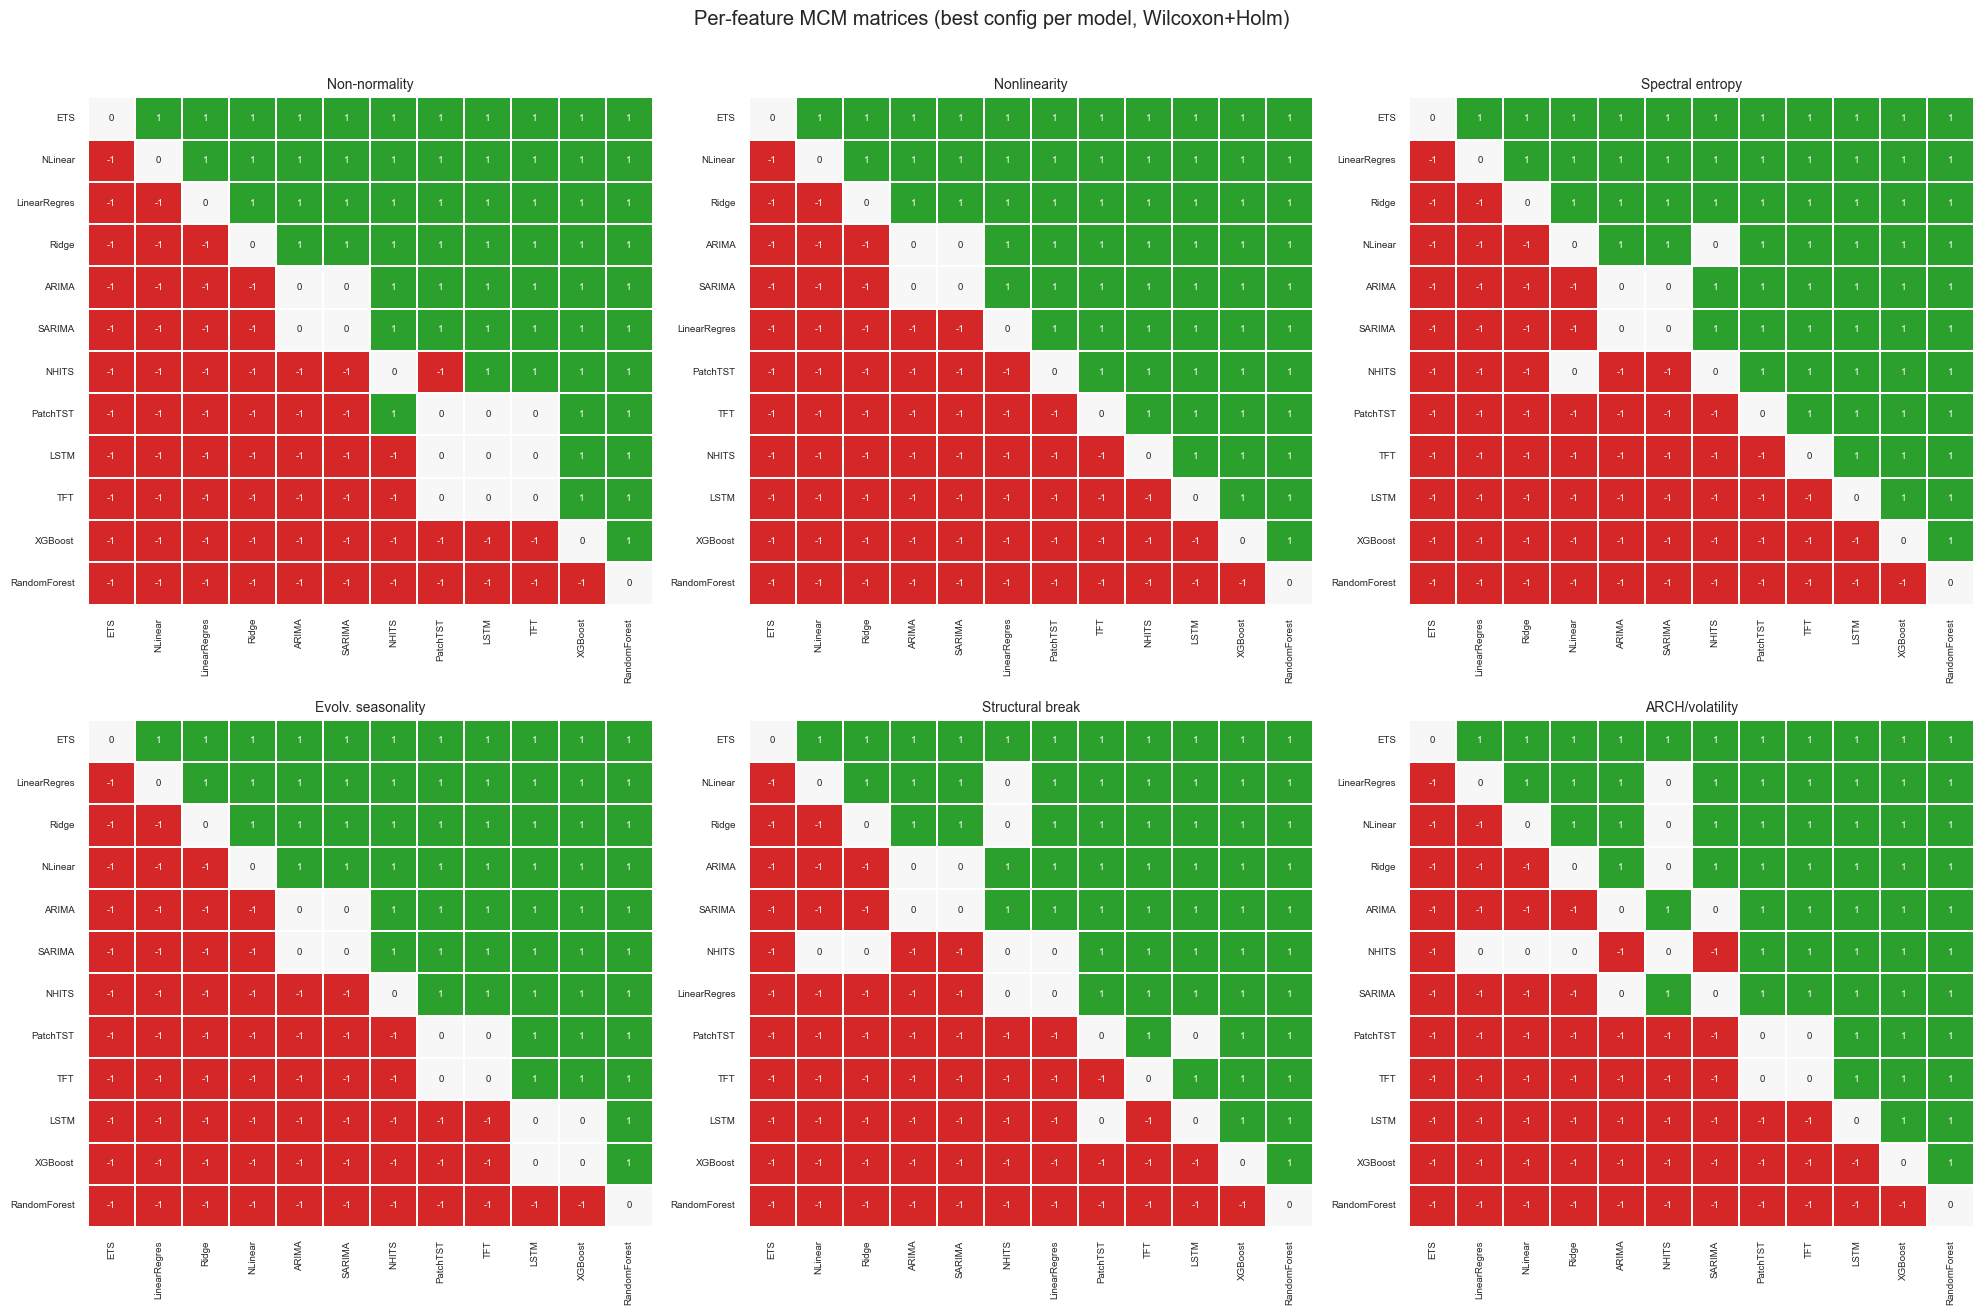

In [8]:
feature_mcms = {}
fig, axes = plt.subplots(2, 3, figsize=(20, 13))
axes_flat = axes.flatten()

for ax, feat in zip(axes_flat, FEATURES):
    feat_data = perf_best[perf_best["feature_name"]==feat]
    mcm_f = pairwise_mcm(feat_data, "model_name", "rel_naive_clipped",
                          ["unique_id","window"])
    feature_mcms[feat] = mcm_f

    order_f = mcm_f.sum(axis=1).sort_values(ascending=False).index.tolist()
    mcm_f_ord = mcm_f.loc[order_f, order_f]
    short = {m: m.replace("Auto","")[:12] for m in order_f}
    mcm_f_plot = mcm_f_ord.rename(index=short, columns=short)
    sns.heatmap(mcm_f_plot, ax=ax, cmap=cmap, center=0, vmin=-1, vmax=1,
                annot=True, fmt="d", linewidths=0.3, cbar=False,
                annot_kws={"size":7})
    ax.set_title(FEAT_SHORT[feat], fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.tick_params(axis="both", labelsize=7)

fig.suptitle("Per-feature MCM matrices (best config per model, Wilcoxon+Holm)", y=1.01)
fig.tight_layout()
plt.savefig(DATA / "fig_mcm_per_feature.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
# Feature-level win scores
print("Net win scores per feature:")
header = f"{'Model':<25}" + "".join(f"  {FEAT_SHORT[f][:14]:<14}" for f in FEATURES)
print(header)
print("-"*len(header))
all_models_sorted = perf["model_name"].unique()
for model in sorted(all_models_sorted):
    row = f"{model:<25}"
    for feat in FEATURES:
        mcm_f = feature_mcms[feat]
        score = mcm_f.loc[model, :].sum() if model in mcm_f.index else 0
        row += f"  {score:+3d}           "
    print(row)


Net win scores per feature:
Model                      Non-normality   Nonlinearity    Spectral entro  Evolv. seasona  Structural bre  ARCH/volatilit
-------------------------------------------------------------------------------------------------------------------------
AutoARIMA                   +2              +4              +2              +2              +4              +2           
AutoETS                    +11             +11             +11             +11             +11             +11           
AutoLSTM                    -5              -7              -7              -8              -6              -7           
AutoLinearRegression        +7              +1              +9              +9              +0              +8           
AutoNHITS                   -3              -5              +0              -1              +2              +2           
AutoNLinear                 +9              +9              +4              +5              +8              +6        

## 5  Best (Finetune × Decomposition) Config per Model per Feature

For each model × feature combination, find the configuration with the lowest median
RelNaive. Test whether it is statistically better than the reference
(global baseline + Direct decomposition) using Wilcoxon + Holm.

**Significance:** ✓ = significantly better than reference at p_Holm < 0.05,
✗ = significantly worse, ~ = no significant difference.


In [10]:
REFERENCE_DECOMP = "without_stl"
# For NL: reference is no_finetune + without_stl rows in master
# For linear/stat: reference is no_finetune + without_stl

# Get reference rows for all models
ref_rows = master[
    (master["finetuning_mode"]=="no_finetune") &
    (master["decomposition_method"]==REFERENCE_DECOMP) &
    (master["model_name"].isin(ALL_MODELS))
].copy()

results = []

for feat in FEATURES:
    feat_perf = perf[perf["feature_name"]==feat]
    feat_ref  = ref_rows[ref_rows["feature_name"]==feat]

    for model in ALL_MODELS:
        m_rows = feat_perf[feat_perf["model_name"]==model]
        if m_rows.empty: continue

        # All configs for this model × feature
        configs = []
        for (cfg, decomp), grp in m_rows.groupby(["config","decomposition_method"]):
            configs.append({
                "config": cfg, "decomp": decomp,
                "median": grp["rel_naive_clipped"].median(),
                "mean":   grp["rel_naive_clipped"].mean(),
                "n":      len(grp),
                "values": grp.set_index(["unique_id","window"])["rel_naive_clipped"],
            })
        if not configs: continue

        best_cfg = min(configs, key=lambda x: x["median"])

        # Reference for this model × feature
        ref = feat_ref[feat_ref["model_name"]==model]
        ref_vals = ref.set_index(["unique_id","window"])["rel_naive_clipped"]
        best_vals = best_cfg["values"]
        common = best_vals.index.intersection(ref_vals.index)

        sig = "~"
        p_val = np.nan
        if len(common) >= 20:
            diff = best_vals.loc[common].values - ref_vals.loc[common].values
            if not np.all(diff == 0):
                try:
                    _, p_val = wilcoxon(diff)
                except: pass

        results.append({
            "feature_name": feat,
            "model_name":   model,
            "best_config":  best_cfg["config"],
            "best_decomp":  best_cfg["decomp"],
            "best_median":  round(best_cfg["median"], 4),
            "ref_median":   round(ref_vals.median(), 4) if not ref.empty else np.nan,
            "delta":        round(ref_vals.median() - best_cfg["median"], 4) if not ref.empty else np.nan,
            "n_common":     len(common),
            "p_raw":        p_val,
        })

results_df = pd.DataFrame(results)

# Holm correction per feature
sig_col = []
for feat, grp in results_df.groupby("feature_name"):
    valid = grp["p_raw"].notna()
    if valid.sum() == 0:
        sig_col.extend(["~"] * len(grp)); continue
    ps = grp.loc[valid, "p_raw"].values
    reject, p_holm, _, _ = multipletests(ps, method="holm")
    rej_map = dict(zip(grp.loc[valid].index, reject))
    delta_map = dict(zip(grp.index, grp["delta"]))
    for idx in grp.index:
        rej = rej_map.get(idx, False)
        d   = delta_map.get(idx, 0) or 0
        if rej and d > 0:   sig_col.append("✓")
        elif rej and d < 0: sig_col.append("✗")
        else:               sig_col.append("~")

results_df["significant"] = sig_col
results_df["best_decomp_label"] = results_df["best_decomp"].map(DECOMP_LABELS)

print(f"Best config analysis: {len(results_df)} entries")
print(results_df["significant"].value_counts().to_string())
results_df.to_csv(DATA / "table_best_config_per_feature.csv", index=False)


Best config analysis: 72 entries
significant
✓    49
~    23


In [11]:
# Pivot table: feature × model — show "best_decomp (sig)"
pivot_label = results_df.pivot(index="model_name", columns="feature_name",
                                values=["best_decomp_label","significant","delta"])

# Build readable table
summary_rows = []
for model in ALL_MODELS:
    row = {"model": model}
    for feat in FEATURES:
        sub = results_df[(results_df["model_name"]==model) & (results_df["feature_name"]==feat)]
        if sub.empty:
            row[FEAT_SHORT[feat]] = "—"
        else:
            r = sub.iloc[0]
            cfg_tag = "FT" if r["best_config"]=="finetuned" else "GL"
            sig_tag = r["significant"]
            row[FEAT_SHORT[feat]] = f"{r['best_decomp_label']}/{cfg_tag} {sig_tag}"
    summary_rows.append(row)

summary_tbl = pd.DataFrame(summary_rows).set_index("model")
print("Best (decomp/config) per model per feature (FT=finetuned, GL=global, ✓=sig.better, ✗=sig.worse, ~=no sig diff):")
print(summary_tbl.to_string())
summary_tbl.to_csv(DATA / "table_best_config_summary.csv")


Best (decomp/config) per model per feature (FT=finetuned, GL=global, ✓=sig.better, ✗=sig.worse, ~=no sig diff):
                     Non-normality Nonlinearity Spectral entropy Evolv. seasonality Structural break ARCH/volatility
model                                                                                                               
AutoXGBoost            Direct/FT ✓  Direct/FT ✓      Direct/FT ✓        Direct/FT ✓      Direct/FT ✓     Direct/FT ✓
AutoLSTM               STL-AC/FT ✓  STL-AC/FT ✓      Direct/FT ✓        STL-AC/FT ✓      STL-AC/FT ✓     STL-AC/FT ✓
AutoRandomForest       Direct/FT ✓  Direct/FT ~      Direct/FT ~        Direct/FT ~      Direct/FT ~     Direct/FT ~
AutoNHITS              Direct/FT ✓  Direct/FT ✓      Direct/FT ✓        Direct/FT ✓      Direct/FT ✓     Direct/FT ✓
AutoTFT                Direct/FT ✓  Direct/FT ✓      Direct/FT ✓        Direct/FT ✓      Direct/FT ✓     Direct/FT ✓
AutoPatchTST           Direct/FT ✓  Direct/FT ✓      Direct/FT ✓     

C:\Users\diogo\AppData\Local\Temp\claude\ipykernel_24384\2279182352.py:38: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\claude\ipykernel_24384\2279182352.py:38: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\diogo\AppData\Local\Temp\claude\ipykernel_24384\2279182352.py:39: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(DATA / "fig_best_config_heatmap.png", dpi=150, bbox_inches="tight")
C:\Users\diogo\AppData\Local\Temp\claude\ipykernel_24384\2279182352.py:39: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig(DATA / "fig_best_config_heatmap.png", dpi=150, bbox_inches="tight")


C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\diogo\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


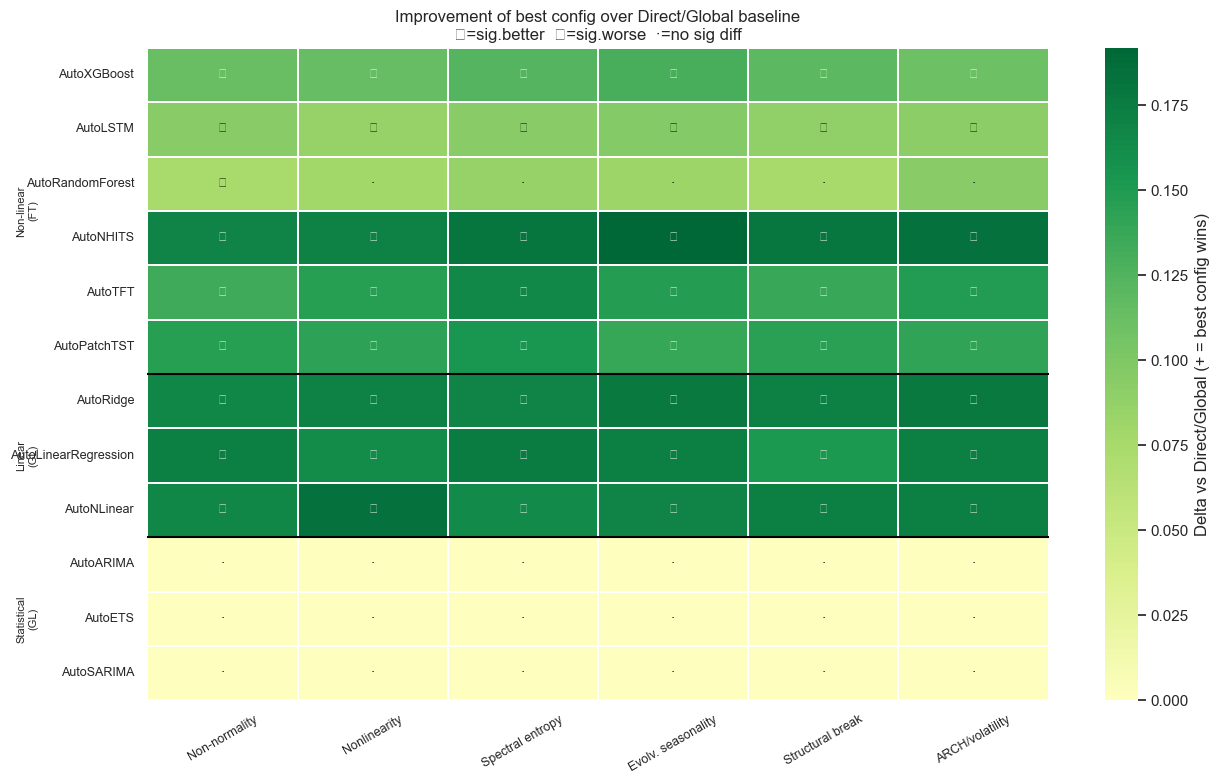

In [12]:
# Heatmap: delta (ref_median - best_median) per model × feature
delta_pivot = results_df.pivot(index="model_name", columns="feature_name", values="delta")
delta_pivot = delta_pivot.reindex(index=ALL_MODELS,
                                   columns=FEATURES)
delta_pivot.columns = [FEAT_SHORT[f] for f in delta_pivot.columns]

sig_pivot = results_df.pivot(index="model_name", columns="feature_name", values="significant")
sig_pivot = sig_pivot.reindex(index=ALL_MODELS, columns=FEATURES)

fig, ax = plt.subplots(figsize=(13, 8))
sns.heatmap(delta_pivot, ax=ax, cmap="RdYlGn", center=0,
            annot=False, linewidths=0.3,
            cbar_kws={"label":"Delta vs Direct/Global (+ = best config wins)"})

# Overlay significance markers
for i, model in enumerate(delta_pivot.index):
    for j, feat in enumerate(FEATURES):
        sig = sig_pivot.loc[model, feat] if (model in sig_pivot.index and feat in sig_pivot.columns) else "~"
        d = delta_pivot.iloc[i, j]
        if pd.notna(d):
            marker = "★" if sig=="✓" else ("✗" if sig=="✗" else "·")
            ax.text(j+0.5, i+0.5, marker, ha="center", va="center", fontsize=9,
                    color="black" if abs(d) < 0.1 else "white")

ax.set_title("Improvement of best config over Direct/Global baseline\n★=sig.better  ✗=sig.worse  ·=no sig diff")
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(axis="x", rotation=30, labelsize=9)
ax.tick_params(axis="y", labelsize=9)
# Draw separator lines
ax.axhline(len(NL_MODELS),     color="black", lw=1.5)
ax.axhline(len(NL_MODELS)+len(LIN_MODELS), color="black", lw=1.5)
ax.text(-0.8, len(NL_MODELS)/2, "Non-linear\n(FT)", va="center", ha="center",
        fontsize=8, rotation=90)
ax.text(-0.8, len(NL_MODELS)+len(LIN_MODELS)/2, "Linear\n(GL)", va="center",
        ha="center", fontsize=8, rotation=90)
ax.text(-0.8, len(NL_MODELS)+len(LIN_MODELS)+len(STAT_MODELS)/2, "Statistical\n(GL)",
        va="center", ha="center", fontsize=8, rotation=90)
fig.tight_layout()
plt.savefig(DATA / "fig_best_config_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


## 6  Summary: Which Model × Config Wins Each Feature?

In [13]:
# For each feature: which model has the best median RelNaive in its best config?
winners = []
for feat in FEATURES:
    feat_best = results_df[results_df["feature_name"]==feat].sort_values("best_median")
    if feat_best.empty: continue
    top3 = feat_best.head(3)
    winners.append({
        "Feature": FEAT_SHORT[feat],
        "1st": f"{top3.iloc[0]['model_name']} ({top3.iloc[0]['best_decomp_label']}/{('FT' if top3.iloc[0]['best_config']=='finetuned' else 'GL')}) {top3.iloc[0]['best_median']:.3f} {top3.iloc[0]['significant']}",
        "2nd": f"{top3.iloc[1]['model_name']} ({top3.iloc[1]['best_decomp_label']}/{('FT' if top3.iloc[1]['best_config']=='finetuned' else 'GL')}) {top3.iloc[1]['best_median']:.3f} {top3.iloc[1]['significant']}",
        "3rd": f"{top3.iloc[2]['model_name']} ({top3.iloc[2]['best_decomp_label']}/{('FT' if top3.iloc[2]['best_config']=='finetuned' else 'GL')}) {top3.iloc[2]['best_median']:.3f} {top3.iloc[2]['significant']}",
    })
winners_df = pd.DataFrame(winners)
print(winners_df.to_string(index=False))
winners_df.to_csv(DATA / "table_feature_winners.csv", index=False)


           Feature                         1st                           2nd                            3rd
     Non-normality AutoETS (Direct/GL) 0.791 ~ AutoARIMA (Direct/GL) 0.798 ~ AutoSARIMA (Direct/GL) 0.798 ~
      Nonlinearity AutoETS (Direct/GL) 0.791 ~ AutoARIMA (Direct/GL) 0.798 ~ AutoSARIMA (Direct/GL) 0.798 ~
  Spectral entropy AutoETS (Direct/GL) 0.791 ~ AutoARIMA (Direct/GL) 0.798 ~ AutoSARIMA (Direct/GL) 0.798 ~
Evolv. seasonality AutoETS (Direct/GL) 0.791 ~ AutoARIMA (Direct/GL) 0.798 ~ AutoSARIMA (Direct/GL) 0.798 ~
  Structural break AutoETS (Direct/GL) 0.791 ~ AutoARIMA (Direct/GL) 0.798 ~ AutoSARIMA (Direct/GL) 0.798 ~
   ARCH/volatility AutoETS (Direct/GL) 0.791 ~ AutoARIMA (Direct/GL) 0.798 ~ AutoSARIMA (Direct/GL) 0.798 ~


In [14]:
# Final summary stats
print("="*60)
print("SUMMARY")
print("="*60)
sig_better = results_df[results_df["significant"]=="✓"]
sig_worse  = results_df[results_df["significant"]=="✗"]
no_sig     = results_df[results_df["significant"]=="~"]

print(f"Total model×feature configs: {len(results_df)}")
print(f"  Best config sig. better than Direct/Global: {len(sig_better)} ({len(sig_better)/len(results_df)*100:.0f}%)")
print(f"  Best config sig. worse:                     {len(sig_worse)} ({len(sig_worse)/len(results_df)*100:.0f}%)")
print(f"  No significant difference:                  {len(no_sig)} ({len(no_sig)/len(results_df)*100:.0f}%)")

print("\nModels with most significant improvements:")
print(sig_better.groupby("model_name").size().sort_values(ascending=False).to_string())

print("\nModels with most significant harms:")
print(sig_worse.groupby("model_name").size().sort_values(ascending=False).head(5).to_string())

print("\nBest decomp choice (most frequent):")
print(results_df.groupby(["model_name","best_decomp_label"]).size().unstack(fill_value=0).to_string())


SUMMARY
Total model×feature configs: 72
  Best config sig. better than Direct/Global: 49 (68%)
  Best config sig. worse:                     0 (0%)
  No significant difference:                  23 (32%)

Models with most significant improvements:
model_name
AutoLSTM                6
AutoLinearRegression    6
AutoNHITS               6
AutoNLinear             6
AutoPatchTST            6
AutoRidge               6
AutoTFT                 6
AutoXGBoost             6
AutoRandomForest        1

Models with most significant harms:
Series([], )

Best decomp choice (most frequent):
best_decomp_label     Direct  STL-AC
model_name                          
AutoARIMA                  6       0
AutoETS                    6       0
AutoLSTM                   1       5
AutoLinearRegression       0       6
AutoNHITS                  6       0
AutoNLinear                0       6
AutoPatchTST               6       0
AutoRandomForest           6       0
AutoRidge                  0       6
AutoSARIMA    